In [24]:
!pip install yfinance

In [25]:
import yfinance as yf
import pandas as pd

df = yf.download("CL=F", start="2000-01-01", end ="2026-03-20")
print(df.head())
df.to_csv("petroleo_historico.csv")

/tmp/ipykernel_643/3140339585.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("CL=F", start="2000-01-01", end ="2026-03-20")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open Volume
Ticker           CL=F       CL=F       CL=F       CL=F   CL=F
Date                                                         
2000-08-23  32.049999  32.799999  31.950001  31.950001  79385
2000-08-24  31.629999  32.240002  31.400000  31.900000  72978
2000-08-25  32.049999  32.099998  31.320000  31.700001  44601
2000-08-28  32.869999  32.919998  31.860001  32.040001  46770
2000-08-29  32.720001  33.029999  32.560001  32.820000  49131


In [26]:
print(df.shape)

(6421, 5)


In [27]:
print(df.isnull().sum())

Price   Ticker
Close   CL=F      1
High    CL=F      1
Low     CL=F      1
Open    CL=F      1
Volume  CL=F      0
dtype: int64


In [28]:
print(df["Close"].describe())

Ticker         CL=F
count   6420.000000
mean      64.700972
std       24.514490
min      -37.630001
25%       46.447500
50%       63.684999
75%       81.910004
max      145.289993


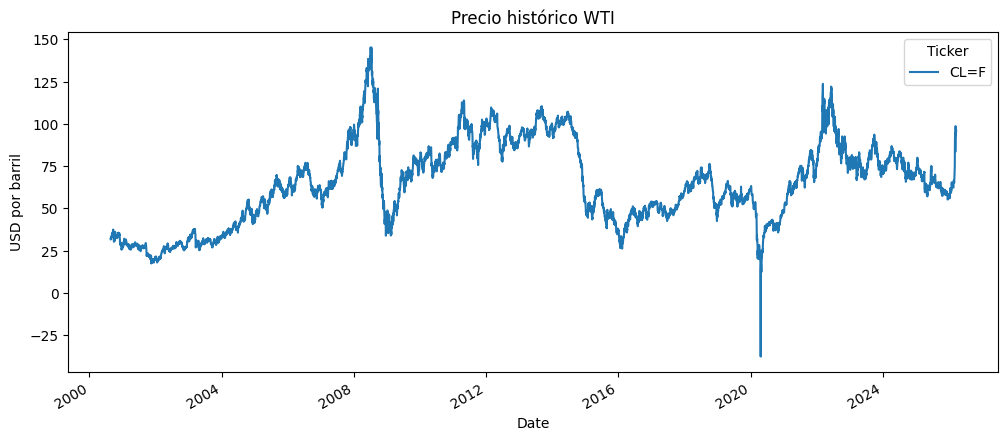

In [29]:
import matplotlib.pyplot as plt

df["Close"].plot(figsize=(12,5), title="Precio histórico WTI")
plt.ylabel("USD por barril")
plt.show()

In [30]:
df = df.dropna()
df = df[:-1]
print(df.isnull().sum())

Price   Ticker
Close   CL=F      0
High    CL=F      0
Low     CL=F      0
Open    CL=F      0
Volume  CL=F      0
dtype: int64


In [31]:
df.to_csv("petroleo_historico.csv")

In [41]:
df.columns = df.columns.get_level_values(0)
df = df[["Close", "High", "Low", "Open", "Volume"]].copy()

df["Target"] = df["Close"].shift(-1)
df = df.dropna()
print(df[["Close", "Target"]].head(10))

Price           Close     Target
Date                            
2000-08-23  32.049999  31.629999
2000-08-24  31.629999  32.049999
2000-08-25  32.049999  32.869999
2000-08-28  32.869999  32.720001
2000-08-29  32.720001  33.400002
2000-08-30  33.400002  33.099998
2000-08-31  33.099998  33.380001
2000-09-01  33.380001  33.799999
2000-09-05  33.799999  34.950001
2000-09-06  34.950001  35.330002


In [42]:
split = int(len(df) * 0.8)

train = df.iloc[: split]
test = df.iloc[split :]

print(f"Entrenamiento: {len(train)} filas")
print(f"Test: {len(test)} filas")

Entrenamiento: 5134 filas
Test: 1284 filas


In [43]:
features = ["Close" , "High", "Low", "Open", "Volume"]

X_train = train[features]
y_train = train["Target"]

X_test = test[features]
y_test = test["Target"]

In [44]:
print(X_train.shape)
print(X_test.shape)

(5134, 5)
(1284, 5)


In [45]:
from sklearn.ensemble import RandomForestRegressor

modelo = RandomForestRegressor(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

print("Modelo entrenado")

Modelo entrenado


In [46]:
predicciones = modelo.predict(X_test)

print(predicciones[: 10])
print(y_test.values[: 10])

[58.29880051 58.17130043 58.47630035 58.58570023 58.61599976 59.21709972
 60.75239998 61.30460033 60.00729954 60.80380062]
[58.36000061 58.68000031 58.24000168 59.47000122 60.04999924 61.13999939
 60.52000046 59.24000168 61.49000168 61.66999817]


In [47]:
import pandas as pd

comparacion = pd.DataFrame({
    "Real": y_test.values[:10],
    "Prediccion": predicciones[:10]
})

print(comparacion)


        Real  Prediccion
0  58.360001   58.298801
1  58.680000   58.171300
2  58.240002   58.476300
3  59.470001   58.585700
4  60.049999   58.616000
5  61.139999   59.217100
6  60.520000   60.752400
7  59.240002   61.304600
8  61.490002   60.007300
9  61.669998   60.803801


In [48]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predicciones)
print(f"Error medio absoluto: {mae:.2f} dólares")

Error medio absoluto: 1.47 dólares


In [40]:
print(y_test.isnull().sum())
print(X_test.isnull().sum())

1
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [49]:
ultimo_dia = df[features].iloc[-1:]
prediccion_manyana = modelo.predict(ultimo_dia)
print(f"Prediccion para mañana:  {prediccion_manyana[0]:.2f} dolares" )

Prediccion para mañana:  95.93 dolares
